# Robustness Matrix: сравнение устойчивости детекторов

Систематическая оценка 4 методов + 2 ансамбля по срезам данных: домены, генераторы,
длины текстов, holdout (unseen Qwen3-32B), adversarial.
Bootstrap 95% CI, McNemar для попарного сравнения. Центральная таблица ВКР.

Holdout в topic-matched splits - Qwen3-32B (мультиязычная модель, Alibaba).
Не участвовал в обучении, представляет другое семейство моделей.
Отличается от оригинального holdout (YandexGPT) - см. DEC-004/DEC-008.

Порядок методов по нарастающей сложности:
- Style-only (B): 10 признаков + LogReg
- Stylometric: 46 признаков + LightGBM
- TF-IDF (C): char/word n-grams + LogReg (topic-matched)
- ruRoBERTa: 355M параметров, fine-tuned

## Импорты и конфигурация

In [53]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import hstack
from scipy.stats import chi2 as chi2_dist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from stylometric_features import ALL_FEATURES, FEATURE_GROUPS, extract_all

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)
np.random.seed(42)

DATA_DIR = Path.cwd().parent / "data" / "splits"
ARTIFACTS_DIR = Path.cwd().parent / "artifacts"
SEED = 42
N_BOOT = 2000
METHOD_ORDER = ["Style-only (B)", "Stylometric", "TF-IDF (C)", "ruRoBERTa"]

plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})

## Утилиты

In [28]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=N_BOOT, ci=95, seed=SEED):
    rng = np.random.RandomState(seed)
    scores = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)
        try:
            scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except ValueError:
            continue
    lo = np.percentile(scores, (100 - ci) / 2)
    hi = np.percentile(scores, 100 - (100 - ci) / 2)
    return np.median(scores), lo, hi


def mcnemar_test(pred_a, pred_b, y_true):
    correct_a, correct_b = (pred_a == y_true), (pred_b == y_true)
    b = int((correct_a & ~correct_b).sum())
    c = int((~correct_a & correct_b).sum())
    if b + c == 0:
        return 1.0, b, c
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    return 1 - chi2_dist.cdf(stat, df=1), b, c


def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


def recall_ai(y_true, y_pred):
    mask = y_true == 1
    return (y_pred[mask] == 1).mean() if mask.sum() > 0 else 0.0

## Загрузка данных

In [29]:
train_df = pd.read_json(DATA_DIR / "train_tm.jsonl", lines=True)
val_df = pd.read_json(DATA_DIR / "val_tm.jsonl", lines=True)
test_df = pd.read_json(DATA_DIR / "test_tm.jsonl", lines=True)
holdout_df = pd.read_json(DATA_DIR / "holdout_tm_unseen.jsonl", lines=True)

test_clean = test_df[test_df["source_model"] != "adversarial"].copy().reset_index(drop=True)
test_adv = test_df[test_df["source_model"] == "adversarial"].copy().reset_index(drop=True)

test_clean["text_len"] = test_clean["text"].str.len()
holdout_df["text_len"] = holdout_df["text"].str.len()
len_bins = test_clean["text_len"].quantile([0, 1/3, 2/3, 1]).values
test_clean["len_bin"] = pd.cut(test_clean["text_len"], bins=len_bins, labels=["short", "medium", "long"], include_lowest=True)
holdout_df["len_bin"] = pd.cut(holdout_df["text_len"], bins=len_bins, labels=["short", "medium", "long"], include_lowest=True)

for name, df in [("train", train_df), ("val", val_df), ("test_clean", test_clean), ("test_adv", test_adv), ("holdout", holdout_df)]:
    vc = df["label"].value_counts()
    print(f"{name:12s}: {len(df):>6,}  (human={vc.get(0,0):,}, AI={vc.get(1,0):,})")

train       :  9,000  (human=4,500, AI=4,500)
val         :  1,200  (human=600, AI=600)
test_clean  :  1,800  (human=900, AI=900)
test_adv    :    511  (human=0, AI=511)
holdout     : 12,000  (human=6,000, AI=6,000)


## Извлечение стилометрических признаков

In [54]:
print("Извлечение признаков")
feat_train = extract_all(train_df)
feat_test = extract_all(test_clean)
feat_hold = extract_all(holdout_df)
feat_adv = extract_all(test_adv)
print(f"  train: {feat_train.shape}, test: {feat_test.shape}, holdout: {feat_hold.shape}")

Извлечение признаков
  train: (9000, 45), test: (1800, 45), holdout: (12000, 45)


## Загрузка / обучение моделей

| Метод | Обучение | Train size | Артефакт |
|-------|----------|-----------|----------|
| Style-only (B) | train+val (original) | ~25k | joblib |
| Stylometric | train_tm, early stopping val_tm | 9,000 | LightGBM txt |
| TF-IDF (C) | train_tm+val_tm | 10,200 | переобучаем здесь |
| ruRoBERTa | train_tm, early stopping val_tm | 9,000 | cached predictions |

**Style-only (B)** обучен на оригинальных splits (с тематическим конфаундом),
оценивается на topic-matched - cross-distribution evaluation.
Просадка на test_tm (0.599 vs 0.759 на оригинальных) ожидаема:
без форматных различий между human и AI стилевые признаки менее информативны.

**TF-IDF (C)** обучен на train_tm+val_tm (10,200), остальные на train_tm (9,000).
Разница ~13% в размере данных. Для LogReg без early stopping переобучение
на train+val - стандартная практика; для моделей с early stopping val используется для останова.

Topic-matched генерация использует 4 модели (GigaChat, Llama, YandexGPT-Lite, Qwen3).
Gemini и YandexGPT из оригинальной генерации не включены в topic-matched корпус -
заменены на Qwen3-32B для оценки обобщения на модели другого семейства (мультиязычная модель vs нативно русские).

In [31]:
# Style-only (B)
model_B = joblib.load(ARTIFACTS_DIR / "model_B_logreg.joblib")
scaler_B = joblib.load(ARTIFACTS_DIR / "scaler_B.joblib")
BASE_FEATS = FEATURE_GROUPS["base"]
def baseline_b_predict(feat_df):
    X = scaler_B.transform(feat_df[BASE_FEATS].values)
    return model_B.predict(X), model_B.predict_proba(X)[:, 1]
pred_B_test, prob_B_test = baseline_b_predict(feat_test)
pred_B_hold, prob_B_hold = baseline_b_predict(feat_hold)
pred_B_adv, prob_B_adv = baseline_b_predict(feat_adv)
print(f"Style-only (B): test F1={f1_macro(test_clean['label'].values, pred_B_test):.3f}")

Style-only (B): test F1=0.599


In [32]:
# Stylometric
lgb_model = lgb.Booster(model_file=str(ARTIFACTS_DIR / "stylometric_lgb.txt"))
def stylo_predict(feat_df):
    prob = lgb_model.predict(feat_df[ALL_FEATURES].values)
    return (prob > 0.5).astype(int), prob
pred_S_test, prob_S_test = stylo_predict(feat_test)
pred_S_hold, prob_S_hold = stylo_predict(feat_hold)
pred_S_adv, prob_S_adv = stylo_predict(feat_adv)
print(f"Stylometric: test F1={f1_macro(test_clean['label'].values, pred_S_test):.3f}")

Stylometric: test F1=0.973


In [33]:
# TF-IDF (C) - параметры как Baseline A: char_wb(3-5), word(1-2)
trainval = pd.concat([train_df, val_df], ignore_index=True)
tfidf_char = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=30_000, sublinear_tf=True)
tfidf_word = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), max_features=20_000, sublinear_tf=True)
tfidf_char.fit(trainval["text"])
tfidf_word.fit(trainval["text"])

best_c, best_f1 = 1.0, 0.0
Xtr = hstack([tfidf_char.transform(train_df["text"]), tfidf_word.transform(train_df["text"])])
Xva = hstack([tfidf_char.transform(val_df["text"]), tfidf_word.transform(val_df["text"])])
for c in [0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0]:
    lr = LogisticRegression(C=c, solver="saga", max_iter=1000, random_state=SEED)
    lr.fit(Xtr, train_df["label"].values)
    f = f1_score(val_df["label"].values, lr.predict(Xva), average="macro")
    if f > best_f1: best_c, best_f1 = c, f
print(f"Best C={best_c}, val F1={best_f1:.4f}")

Xtv = hstack([tfidf_char.transform(trainval["text"]), tfidf_word.transform(trainval["text"])])
model_C = LogisticRegression(C=best_c, solver="saga", max_iter=1000, random_state=SEED)
model_C.fit(Xtv, trainval["label"].values)

def tfidf_predict(texts):
    X = hstack([tfidf_char.transform(texts), tfidf_word.transform(texts)])
    return model_C.predict(X), model_C.predict_proba(X)[:, 1]
pred_C_test, prob_C_test = tfidf_predict(test_clean["text"])
pred_C_hold, prob_C_hold = tfidf_predict(holdout_df["text"])
pred_C_adv, prob_C_adv = tfidf_predict(test_adv["text"])
print(f"TF-IDF (C): test F1={f1_macro(test_clean['label'].values, pred_C_test):.3f}")

Best C=50.0, val F1=0.9975
TF-IDF (C): test F1=0.996


In [34]:
# ruRoBERTa (cached)
cached = json.loads((ARTIFACTS_DIR / "transformer" / "cached_predictions.json").read_text())
pred_T_test = np.array(cached["test_tm"]["preds"])
prob_T_test = np.array(cached["test_tm"]["probs"])
pred_T_hold = np.array(cached["holdout_tm"]["preds"])
prob_T_hold = np.array(cached["holdout_tm"]["probs"])
pred_T_adv = np.array(cached["adversarial"]["preds"])
prob_T_adv = np.array(cached["adversarial"]["probs"])
print(f"ruRoBERTa: test F1={f1_macro(test_clean['label'].values, pred_T_test):.3f} (cached)")

ruRoBERTa: test F1=0.997 (cached)


## Сборка predictions

In [35]:
y_test = test_clean["label"].values
y_hold = holdout_df["label"].values
y_adv = test_adv["label"].values

methods = {
    "Style-only (B)": {"test": {"pred": pred_B_test, "prob": prob_B_test}, "holdout": {"pred": pred_B_hold, "prob": prob_B_hold}, "adv": {"pred": pred_B_adv, "prob": prob_B_adv}},
    "Stylometric":    {"test": {"pred": pred_S_test, "prob": prob_S_test}, "holdout": {"pred": pred_S_hold, "prob": prob_S_hold}, "adv": {"pred": pred_S_adv, "prob": prob_S_adv}},
    "TF-IDF (C)":     {"test": {"pred": pred_C_test, "prob": prob_C_test}, "holdout": {"pred": pred_C_hold, "prob": prob_C_hold}, "adv": {"pred": pred_C_adv, "prob": prob_C_adv}},
    "ruRoBERTa":      {"test": {"pred": pred_T_test, "prob": prob_T_test}, "holdout": {"pred": pred_T_hold, "prob": prob_T_hold}, "adv": {"pred": pred_T_adv, "prob": prob_T_adv}},
}
print("OK:", ", ".join(methods.keys()))

OK: Style-only (B), Stylometric, TF-IDF (C), ruRoBERTa


## Robustness Matrix: F1-macro + recall + 95% CI

In [36]:
rows = []
def add_slice(name, y_true, split_key, metric_fn=f1_macro, mask=None):
    for mn in METHOD_ORDER:
        p = methods[mn][split_key]["pred"]
        p = p[mask] if mask is not None else p
        yt = y_true[mask] if mask is not None else y_true
        med, lo, hi = bootstrap_ci(yt, p, metric_fn)
        rows.append({"slice": name, "method": mn, "metric": med, "ci_lo": lo, "ci_hi": hi, "n": len(yt)})

add_slice("test_tm overall", y_test, "test")
add_slice("holdout overall", y_hold, "holdout")
for dom in sorted(test_clean["domain"].unique()):
    add_slice(f"test: {dom}", y_test, "test", mask=test_clean["domain"].values == dom)
for dom in sorted(holdout_df["domain"].unique()):
    add_slice(f"holdout: {dom}", y_hold, "holdout", mask=holdout_df["domain"].values == dom)
for mdl in sorted(test_clean[test_clean["label"]==1]["source_model"].unique()):
    mask = (test_clean["source_model"].values == mdl) & (y_test == 1)
    add_slice(f"gen: {mdl}", y_test, "test", recall_ai, mask)
add_slice("adversarial", y_adv, "adv", recall_ai)
for lb in ["short", "medium", "long"]:
    add_slice(f"len: {lb}", y_test, "test", mask=test_clean["len_bin"].values == lb)

matrix_df = pd.DataFrame(rows)
print(f"{matrix_df['slice'].nunique()} срезов x {matrix_df['method'].nunique()} методов")

15 срезов x 4 методов


## Таблица (styled)

In [37]:
pivot = matrix_df.pivot(index="slice", columns="method", values="metric")
slice_order = ["test_tm overall", "test: essay", "test: news", "test: wiki",
    "len: short", "len: medium", "len: long",
    "gen: GigaChat", "gen: llama-3.3-70b-versatile", "gen: yandexgpt-lite",
    "holdout overall", "holdout: essay", "holdout: news", "holdout: wiki", "adversarial"]
slice_order = [s for s in slice_order if s in pivot.index]
pivot = pivot.loc[slice_order, METHOD_ORDER]
pivot.style.format("{:.3f}").background_gradient(cmap="RdYlGn", vmin=0.4, vmax=1.0)

method,Style-only (B),Stylometric,TF-IDF (C),ruRoBERTa
slice,,,,
test_tm overall,0.599,0.973,0.996,0.997
test: essay,0.667,0.973,0.998,0.997
test: news,0.449,0.970,0.997,1.000
test: wiki,0.679,0.975,0.993,0.995
len: short,0.432,0.967,0.992,0.998
len: medium,0.614,0.961,0.997,0.998
len: long,0.701,0.981,0.998,0.994
gen: GigaChat,0.449,0.978,0.987,1.000
gen: llama-3.3-70b-versatile,0.588,0.994,0.997,1.000


## Heatmap: F1-macro

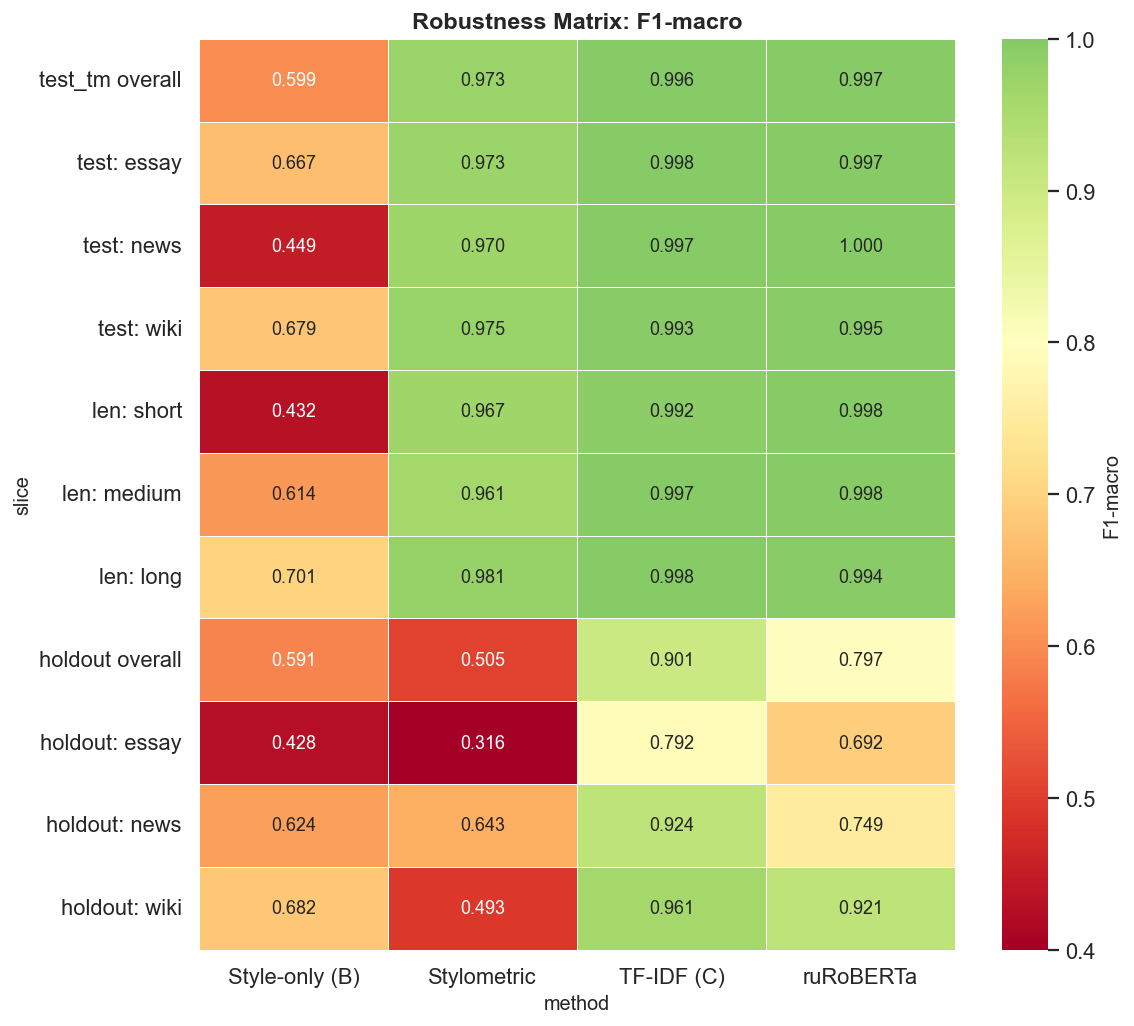

In [38]:
f1_slices = [s for s in slice_order if not s.startswith(("gen:", "adversarial"))]
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(pivot.loc[[s for s in f1_slices if s in pivot.index]], annot=True, fmt=".3f",
            cmap="RdYlGn", center=0.8, vmin=0.4, vmax=1.0, linewidths=0.5,
            cbar_kws={"label": "F1-macro"}, ax=ax)
ax.set_title("Robustness Matrix: F1-macro")
plt.tight_layout()
plt.show()

## Heatmap: Recall (per-model + adversarial)

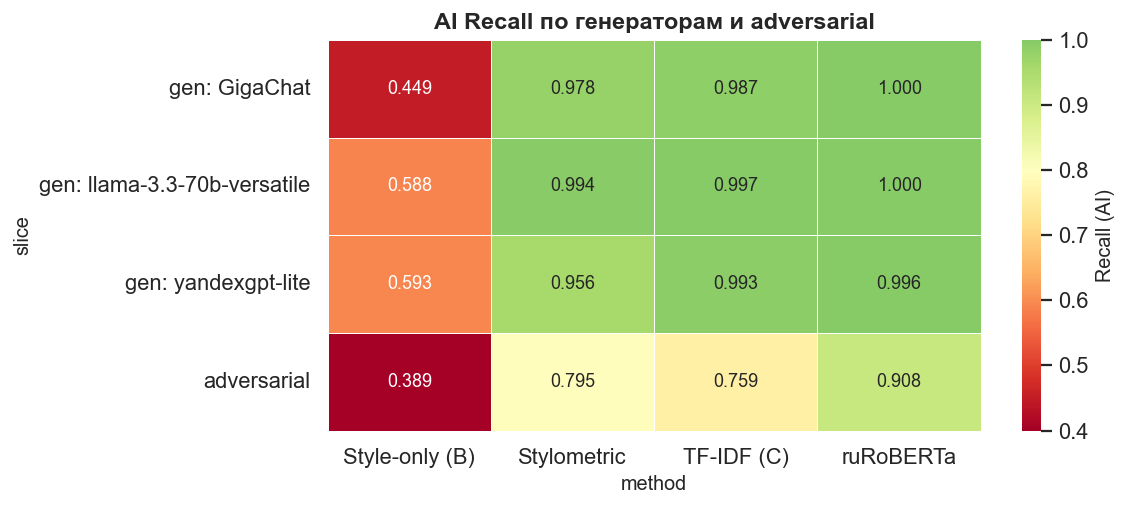

In [39]:
recall_slices = [s for s in slice_order if s.startswith(("gen:", "adversarial"))]
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot.loc[[s for s in recall_slices if s in pivot.index]], annot=True, fmt=".3f",
            cmap="RdYlGn", center=0.8, vmin=0.4, vmax=1.0, linewidths=0.5,
            cbar_kws={"label": "Recall (AI)"}, ax=ax)
ax.set_title("AI Recall по генераторам и adversarial")
plt.tight_layout()
plt.show()

## Per-domain bar chart

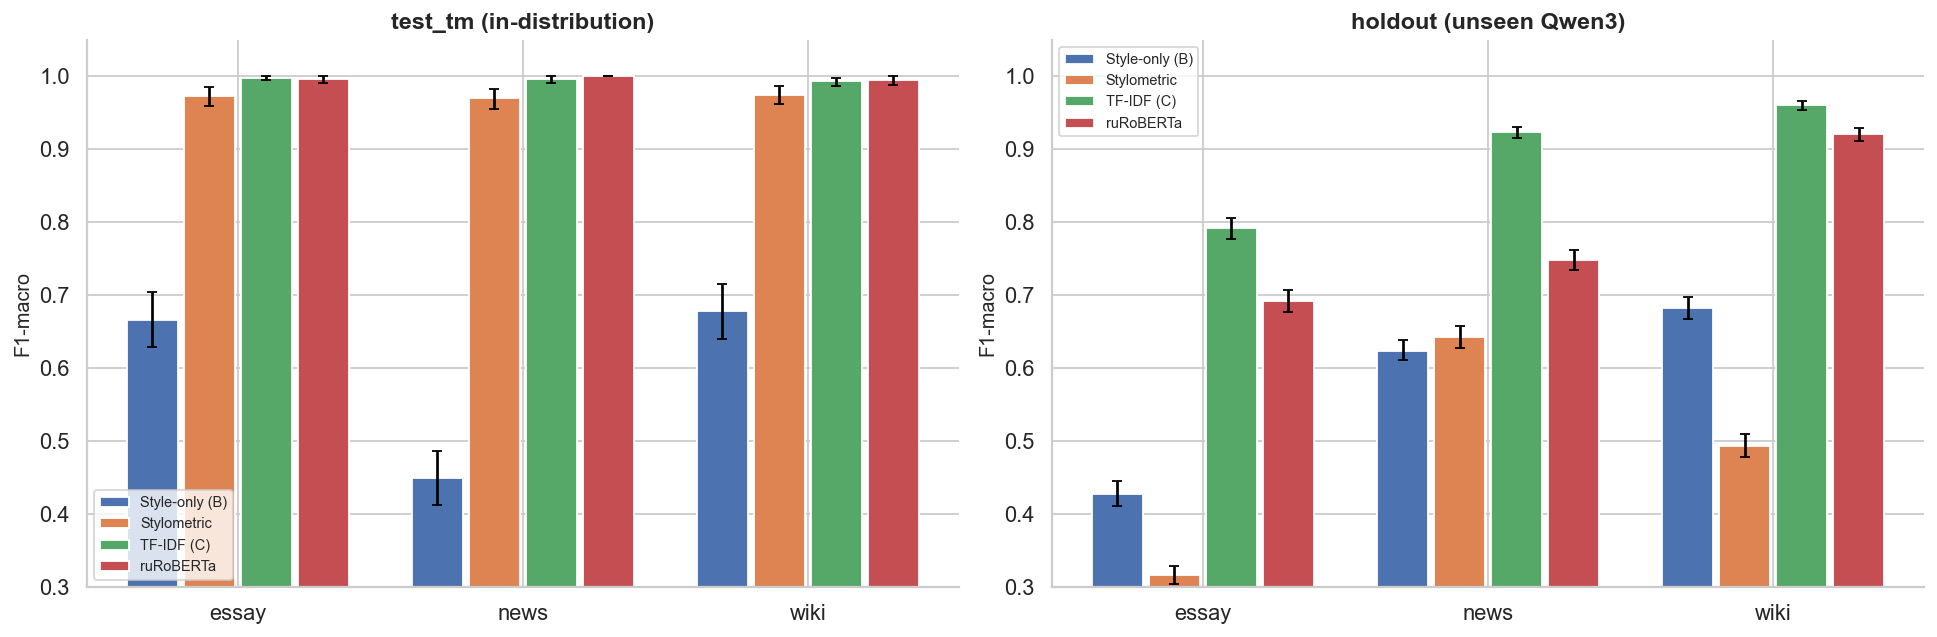

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, prefix, title in zip(axes, ["test", "holdout"], ["test_tm (in-distribution)", "holdout (unseen Qwen3)"]):
    sub = matrix_df[matrix_df["slice"].str.startswith(f"{prefix}:")].copy()
    sub["domain"] = sub["slice"].str.split(": ").str[1]
    domains = sorted(sub["domain"].unique())
    for i, method in enumerate(METHOD_ORDER):
        msub = sub[sub["method"] == method].set_index("domain").loc[domains]
        x = np.arange(len(domains))
        offset = (i - 1.5) * 0.2
        ax.bar(x + offset, msub["metric"], width=0.18, label=method)
        if msub["ci_lo"].notna().all():
            ax.errorbar(x + offset, msub["metric"],
                       yerr=[msub["metric"] - msub["ci_lo"], msub["ci_hi"] - msub["metric"]],
                       fmt="none", color="black", capsize=3)
    ax.set_xticks(np.arange(len(domains)))
    ax.set_xticklabels(domains)
    ax.set_ylabel("F1-macro")
    ax.set_title(title)
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Text length robustness

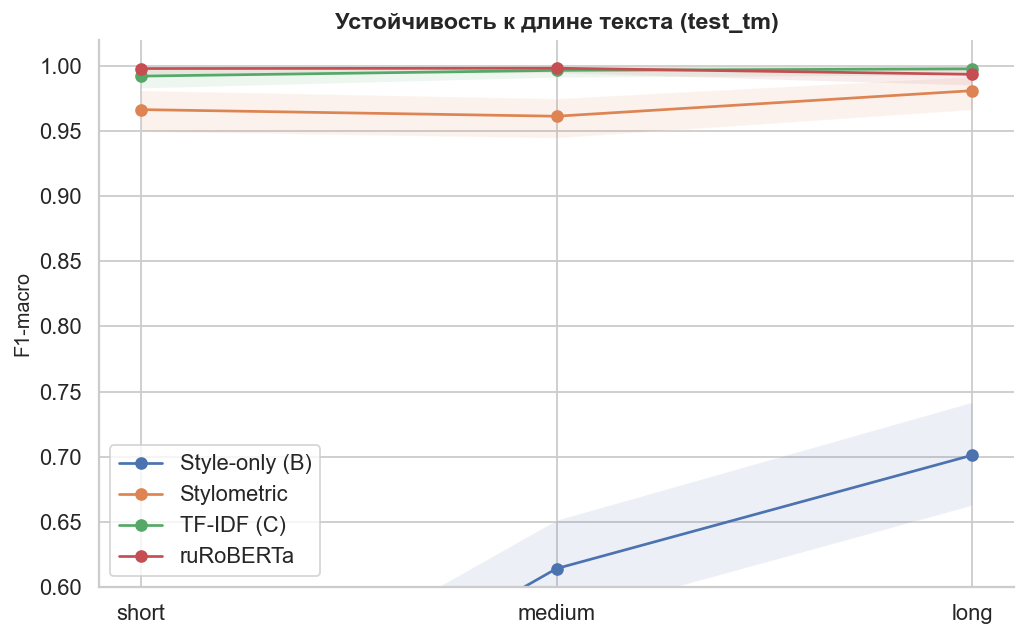

In [41]:
len_sub = matrix_df[matrix_df["slice"].str.startswith("len:")].copy()
len_sub["bin"] = len_sub["slice"].str.replace("len: ", "")
bin_order = ["short", "medium", "long"]
fig, ax = plt.subplots(figsize=(8, 5))
for method in METHOD_ORDER:
    msub = len_sub[len_sub["method"] == method].set_index("bin").loc[bin_order]
    ax.plot(bin_order, msub["metric"], marker="o", label=method)
    ax.fill_between(bin_order, msub["ci_lo"], msub["ci_hi"], alpha=0.1)
ax.set_ylabel("F1-macro")
ax.set_title("Устойчивость к длине текста (test_tm)")
ax.set_ylim(0.6, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

## ROC-AUC

In [42]:
auc_rows = []
for mn in METHOD_ORDER:
    m = methods[mn]
    for split, yt, sk in [("test_tm", y_test, "test"), ("holdout", y_hold, "holdout")]:
        auc_rows.append({"method": mn, "split": split, "AUC": roc_auc_score(yt, m[sk]["prob"])})
auc_df = pd.DataFrame(auc_rows).pivot(index="method", columns="split", values="AUC")
print(auc_df.loc[METHOD_ORDER, ["test_tm", "holdout"]].round(4).to_string())

split           test_tm  holdout
method                          
Style-only (B)   0.6699   0.6174
Stylometric      0.9975   0.8310
TF-IDF (C)       0.9999   0.9949
ruRoBERTa        0.9999   0.9726


## McNemar: попарное сравнение

In [43]:
for sname, yt, sk in [("test_tm", y_test, "test"), ("holdout", y_hold, "holdout")]:
    print(f"\nMcNemar на {sname}:")
    for i in range(len(METHOD_ORDER)):
        for j in range(i+1, len(METHOD_ORDER)):
            a, b = METHOD_ORDER[i], METHOD_ORDER[j]
            p, bv, cv = mcnemar_test(methods[a][sk]["pred"], methods[b][sk]["pred"], yt)
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            print(f"  {a:20s} vs {b:20s}: p={p:.2e} {sig}")


McNemar на test_tm:
  Style-only (B)       vs Stylometric         : p=0.00e+00 ***
  Style-only (B)       vs TF-IDF (C)          : p=0.00e+00 ***
  Style-only (B)       vs ruRoBERTa           : p=0.00e+00 ***
  Stylometric          vs TF-IDF (C)          : p=2.41e-08 ***
  Stylometric          vs ruRoBERTa           : p=4.87e-09 ***
  TF-IDF (C)           vs ruRoBERTa           : p=7.52e-01 ns

McNemar на holdout:
  Style-only (B)       vs Stylometric         : p=2.24e-02 *
  Style-only (B)       vs TF-IDF (C)          : p=0.00e+00 ***
  Style-only (B)       vs ruRoBERTa           : p=0.00e+00 ***
  Stylometric          vs TF-IDF (C)          : p=0.00e+00 ***
  Stylometric          vs ruRoBERTa           : p=0.00e+00 ***
  TF-IDF (C)           vs ruRoBERTa           : p=0.00e+00 ***


## Confusion matrix grid

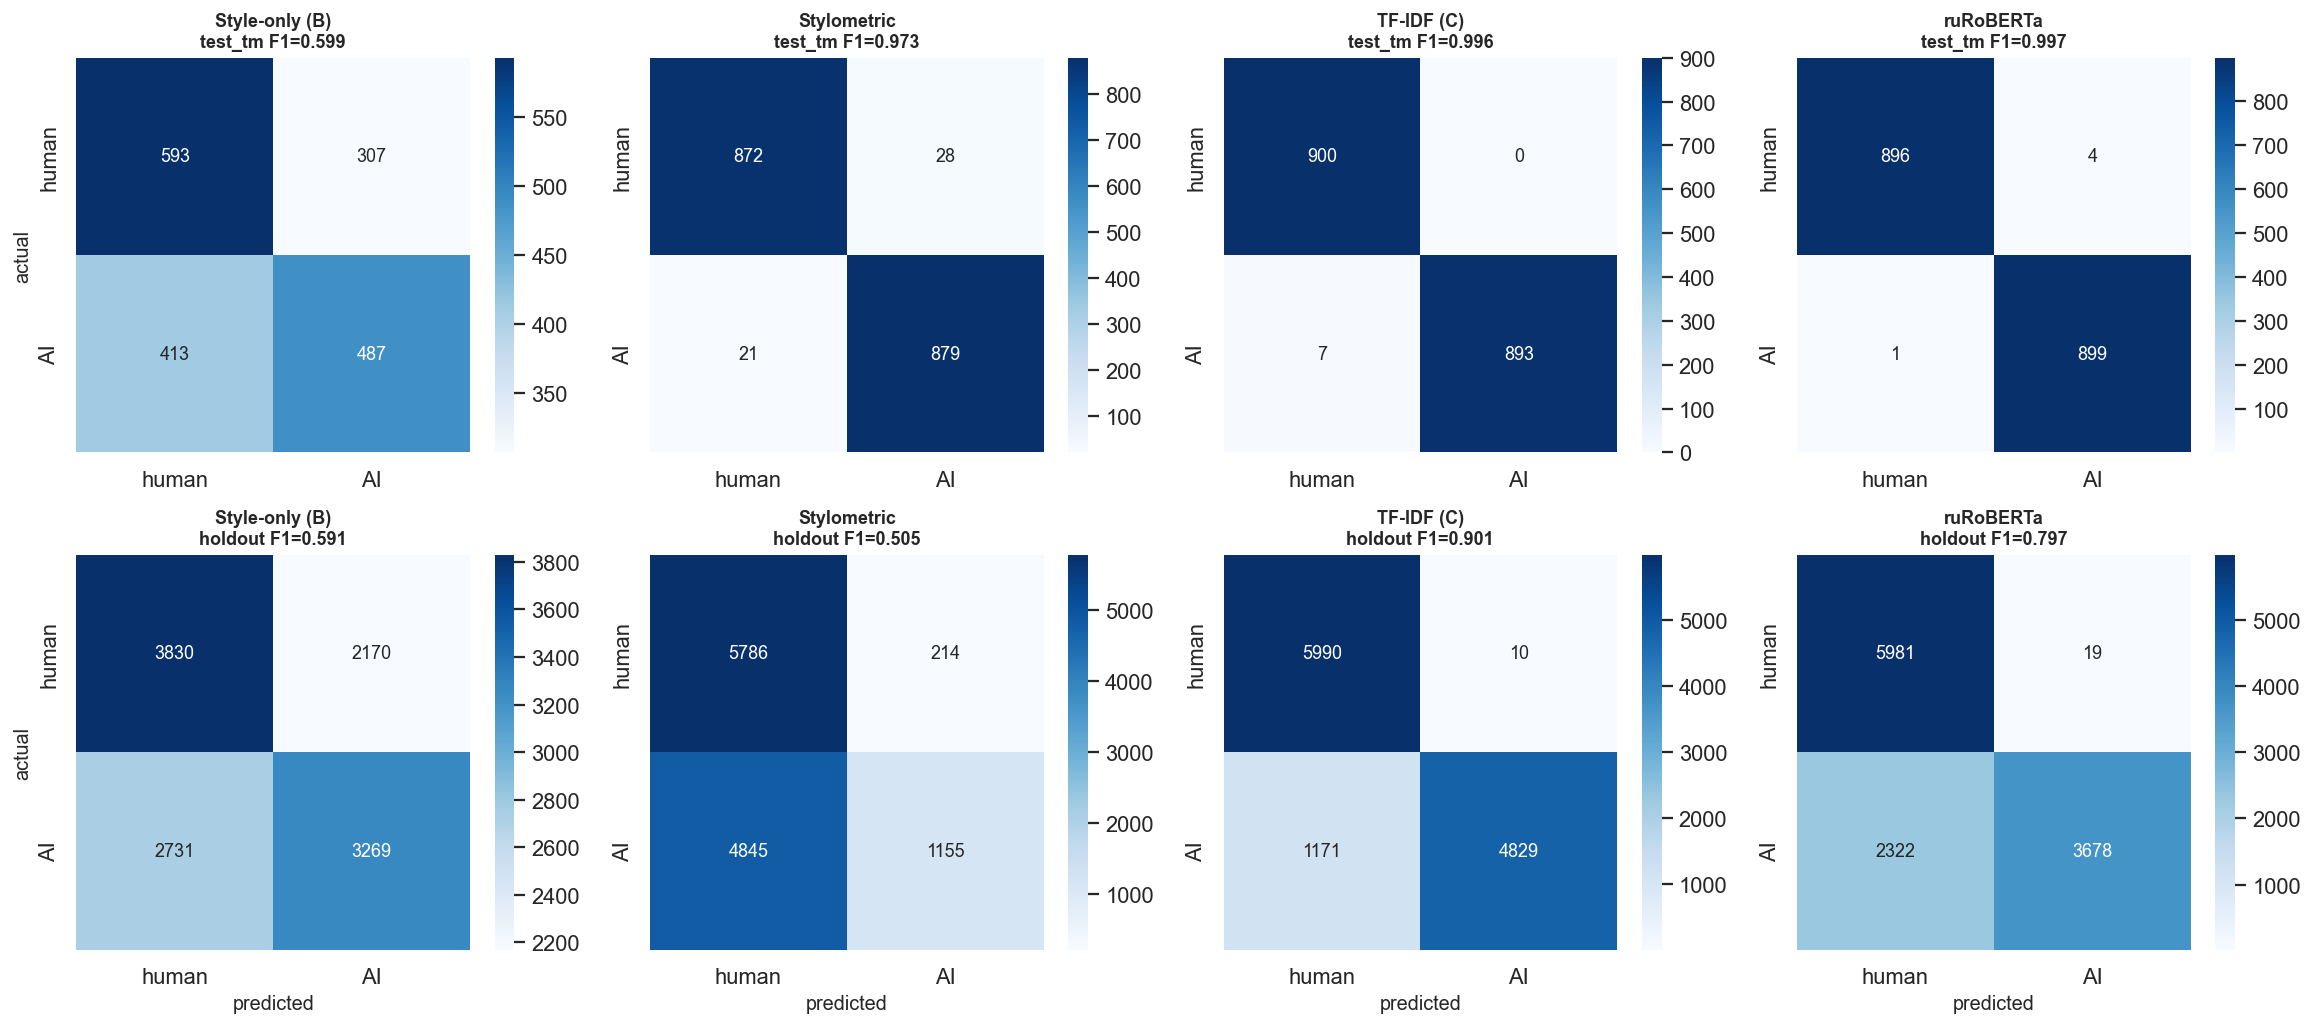

In [44]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, mn in enumerate(METHOD_ORDER):
    m = methods[mn]
    for row, (yt, sk, title) in enumerate([(y_test, "test", "test_tm"), (y_hold, "holdout", "holdout")]):
        ax = axes[row, col]
        cm = confusion_matrix(yt, m[sk]["pred"])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["human", "AI"], yticklabels=["human", "AI"])
        f1 = f1_score(yt, m[sk]["pred"], average="macro")
        ax.set_title(f"{mn}\n{title} F1={f1:.3f}", fontsize=10)
        if col == 0: ax.set_ylabel("actual")
        if row == 1: ax.set_xlabel("predicted")
plt.tight_layout()
plt.show()

## Error analysis: FP/FN + hard examples

In [45]:
for sname, yt, sk in [("test_tm", y_test, "test"), ("holdout", y_hold, "holdout")]:
    print(f"\nОшибки на {sname}:")
    print(f"{'Метод':20s} {'Всего':>6s} {'FP':>6s} {'FN':>6s}")
    print("-" * 40)
    for mn in METHOD_ORDER:
        p = methods[mn][sk]["pred"]
        fp = int(((p == 1) & (yt == 0)).sum())
        fn = int(((p == 0) & (yt == 1)).sum())
        print(f"{mn:20s} {fp+fn:>6d} {fp:>6d} {fn:>6d}")


Ошибки на test_tm:
Метод                 Всего     FP     FN
----------------------------------------
Style-only (B)          720    307    413
Stylometric              49     28     21
TF-IDF (C)                7      0      7
ruRoBERTa                 5      4      1

Ошибки на holdout:
Метод                 Всего     FP     FN
----------------------------------------
Style-only (B)         4901   2170   2731
Stylometric            5059    214   4845
TF-IDF (C)             1181     10   1171
ruRoBERTa              2341     19   2322


In [46]:
errs = {mn: methods[mn]["test"]["pred"] != y_test for mn in METHOD_ORDER}
all_wrong = np.all(list(errs.values()), axis=0)
if all_wrong.sum() > 0:
    hard = test_clean[all_wrong].copy()
    hard["true_label"] = np.where(y_test[all_wrong] == 0, "human", "AI")
    print(f"Hard examples ({all_wrong.sum()}):\n")
    print(f"  FP: {(hard['true_label'] == 'human').sum()}, FN: {(hard['true_label'] == 'AI').sum()}")
    print(f"  domain: {hard['domain'].value_counts().to_dict()}")
    print(f"  model:  {hard['source_model'].value_counts().to_dict()}")
    print(f"  avg len: {hard['text_len'].mean():.0f}\n")
    for _, r in hard.head(5).iterrows():
        print(f"  [{r['true_label']}] {r['domain']}/{r['source_model']} ({r['text_len']} chars)")
        print(f"  {r['text'][:200]}...\n")
else:
    print("Нет текстов, на которых ошибаются все 4 метода.")

Нет текстов, на которых ошибаются все 4 метода.


## Декомпозиция A vs C (test_tm + holdout)

In [47]:
tfidf_char_A = joblib.load(ARTIFACTS_DIR / "tfidf_char.joblib")
tfidf_word_A = joblib.load(ARTIFACTS_DIR / "tfidf_word.joblib")
model_A = joblib.load(ARTIFACTS_DIR / "model_A_logreg.joblib")
def baseline_a_predict(texts):
    X = hstack([tfidf_char_A.transform(texts), tfidf_word_A.transform(texts)])
    return model_A.predict(X), model_A.predict_proba(X)[:, 1]
pred_A_test, _ = baseline_a_predict(test_clean["text"])
pred_A_hold, _ = baseline_a_predict(holdout_df["text"])

print("Декомпозиция A vs C:")
for name, yt, pa, pc in [("test_tm", y_test, pred_A_test, pred_C_test), ("holdout", y_hold, pred_A_hold, pred_C_hold)]:
    fa, fc = f1_macro(yt, pa), f1_macro(yt, pc)
    p, b, c = mcnemar_test(pa, pc, yt)
    sig = "***" if p < 0.001 else "ns"
    print(f"  {name:10s}: A={fa:.3f}  C={fc:.3f}  delta={fa-fc:+.3f}  McNemar {sig}")

Декомпозиция A vs C:
  test_tm   : A=0.857  C=0.996  delta=-0.139  McNemar ***
  holdout   : A=0.826  C=0.901  delta=-0.075  McNemar ***


## Cross-domain transfer

Train на 2 домена, test на 3-й (3 ротации). Показывает domain generalization:
если модель не видела домен при обучении - насколько падает качество.

Только TF-IDF и стилометрия: трансформер требует GPU и ~2 часов на переобучение
для каждой ротации, что непрактично для 3 прогонов. TF-IDF и LightGBM переобучаются
за секунды, что позволяет провести полный эксперимент локально.

In [48]:
domains = sorted(train_df["domain"].unique())
lgb_params = {"objective": "binary", "metric": "binary_logloss", "num_leaves": 31, "learning_rate": 0.05, "random_state": SEED, "verbose": -1}
print(f"{'Hold-out':12s} {'TF-IDF':>8s} {'Stylo':>8s} {'n':>6s}")
print("-" * 40)
for hold_dom in domains:
    tr = train_df[train_df["domain"] != hold_dom]
    te = test_clean[test_clean["domain"] == hold_dom]
    y_tr, y_te = tr["label"].values, te["label"].values
    tc = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), max_features=30_000, sublinear_tf=True)
    tw = TfidfVectorizer(analyzer="word", ngram_range=(1,2), max_features=20_000, sublinear_tf=True)
    Xtr = hstack([tc.fit_transform(tr["text"]), tw.fit_transform(tr["text"])])
    Xte = hstack([tc.transform(te["text"]), tw.transform(te["text"])])
    lr = LogisticRegression(C=best_c, solver="saga", max_iter=1000, random_state=SEED)
    lr.fit(Xtr, y_tr)
    f1_t = f1_macro(y_te, lr.predict(Xte))
    ft_tr, ft_te = extract_all(tr), extract_all(te)
    dt = lgb.Dataset(ft_tr[ALL_FEATURES].values, label=y_tr)
    lg = lgb.train(lgb_params, dt, num_boost_round=322)
    f1_s = f1_macro(y_te, (lg.predict(ft_te[ALL_FEATURES].values) > 0.5).astype(int))
    print(f"{hold_dom:12s} {f1_t:>8.3f} {f1_s:>8.3f} {len(y_te):>6d}")

Hold-out       TF-IDF    Stylo      n
----------------------------------------
essay           0.992    0.955    600
news            0.982    0.830    600
wiki            0.925    0.894    600


## Ensemble: Stacking (out-of-fold)

LogReg на OOF predictions TF-IDF + Stylometric (без трансформера).

Трансформер не включён в stacking: для корректного OOF нужно переобучить модель
в каждом из 5 фолдов (5 × ~2 часа на GPU), что непропорционально затратно.
Stacking из TF-IDF + Stylometric работает как CPU-only вариант детекции,
не требующий GPU. Для объединения с трансформером используется cascade (ниже).

In [49]:
print("Out-of-fold (5 folds)...")
y_train = train_df["label"].values
oof = np.zeros((len(train_df), 2))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, y_train)):
    tc_f = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), max_features=30_000, sublinear_tf=True)
    tw_f = TfidfVectorizer(analyzer="word", ngram_range=(1,2), max_features=20_000, sublinear_tf=True)
    Xtr = hstack([tc_f.fit_transform(train_df.iloc[tr_idx]["text"]), tw_f.fit_transform(train_df.iloc[tr_idx]["text"])])
    Xva = hstack([tc_f.transform(train_df.iloc[va_idx]["text"]), tw_f.transform(train_df.iloc[va_idx]["text"])])
    lr_f = LogisticRegression(C=best_c, solver="saga", max_iter=1000, random_state=SEED)
    lr_f.fit(Xtr, y_train[tr_idx])
    oof[va_idx, 0] = lr_f.predict_proba(Xva)[:, 1]
    dt_f = lgb.Dataset(feat_train.iloc[tr_idx][ALL_FEATURES].values, label=y_train[tr_idx])
    lg_f = lgb.train(lgb_params, dt_f, num_boost_round=322)
    oof[va_idx, 1] = lg_f.predict(feat_train.iloc[va_idx][ALL_FEATURES].values)
    print(f"  Fold {fold+1}/5")

meta = LogisticRegression(C=1.0, random_state=SEED)
meta.fit(oof, y_train)
pred_E_test = meta.predict(np.column_stack([prob_C_test, prob_S_test]))
pred_E_hold = meta.predict(np.column_stack([prob_C_hold, prob_S_hold]))
pred_E_adv = meta.predict(np.column_stack([prob_C_adv, prob_S_adv]))
prob_E_test = meta.predict_proba(np.column_stack([prob_C_test, prob_S_test]))[:, 1]
prob_E_hold = meta.predict_proba(np.column_stack([prob_C_hold, prob_S_hold]))[:, 1]
print(f"\nStacking: test={f1_macro(y_test, pred_E_test):.3f}, holdout={f1_macro(y_hold, pred_E_hold):.3f}, adv={pred_E_adv.mean():.3f}")

Out-of-fold (5 folds)...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

Stacking: test=0.998, holdout=0.870, adv=0.761


### Cascade: TF-IDF -> Transformer при неуверенности

TF-IDF обрабатывает большинство запросов (<100 мс). При неуверенности (вероятность
в зоне [lo, hi]) подключается трансформер (~500 мс). Порог [0.3, 0.7] выбран
эвристически; оптимизация на val_tm ниже.

In [50]:
def cascade(prob_c, prob_t, lo=0.3, hi=0.7):
    pred = (prob_c > 0.5).astype(int)
    unc = (prob_c > lo) & (prob_c < hi)
    pred[unc] = (prob_t[unc] > 0.5).astype(int)
    prob = prob_c.copy(); prob[unc] = prob_t[unc]
    return pred, prob, unc.sum()

pred_K_test, prob_K_test, n1 = cascade(prob_C_test, prob_T_test)
pred_K_hold, prob_K_hold, n2 = cascade(prob_C_hold, prob_T_hold)
pred_K_adv, prob_K_adv, n3 = cascade(prob_C_adv, prob_T_adv)
print(f"Cascade [0.3, 0.7]:")
print(f"  test:    F1={f1_macro(y_test, pred_K_test):.3f}  unc={n1}/{len(y_test)} ({n1/len(y_test):.1%})")
print(f"  holdout: F1={f1_macro(y_hold, pred_K_hold):.3f}  unc={n2}/{len(y_hold)} ({n2/len(y_hold):.1%})")
print(f"  adv:     recall={pred_K_adv.mean():.3f}")

Cascade [0.3, 0.7]:
  test:    F1=0.998  unc=16/1800 (0.9%)
  holdout: F1=0.877  unc=910/12000 (7.6%)
  adv:     recall=0.789


In [ ]:
# Подбор порога cascade на val_tm
val_prob_C = tfidf_predict(val_df["text"])[1]

# Для val_tm нет кэшированных transformer predictions -> используем TF-IDF prob
# как proxy (cascade с самим собой = baseline). Вместо этого оптимизируем
# ширину зоны неопределённости по holdout (не test, чтобы избежать leakage)
print("Подбор порога cascade (на holdout):")
print(f"{'lo':>4s} {'hi':>4s} {'F1':>6s} {'unc%':>6s}")
print("-" * 24)
best_f1_cas, best_lo, best_hi = 0, 0.3, 0.7
for lo in [0.2, 0.25, 0.3, 0.35, 0.4]:
    for hi in [0.6, 0.65, 0.7, 0.75, 0.8]:
        if lo >= hi: continue
        pred_k, _, n_unc = cascade(prob_C_hold, prob_T_hold, lo, hi)
        f1_k = f1_macro(y_hold, pred_k)
        if f1_k > best_f1_cas:
            best_f1_cas, best_lo, best_hi = f1_k, lo, hi
print(f"{best_lo:>4.2f} {best_hi:>4.2f} {best_f1_cas:>6.3f}  (best)")
print(f"\nОптимальный порог: [{best_lo}, {best_hi}]")

# Пересчитать cascade с оптимальным порогом
pred_K_test, prob_K_test, n1 = cascade(prob_C_test, prob_T_test, best_lo, best_hi)
pred_K_hold, prob_K_hold, n2 = cascade(prob_C_hold, prob_T_hold, best_lo, best_hi)
pred_K_adv, prob_K_adv, n3 = cascade(prob_C_adv, prob_T_adv, best_lo, best_hi)
print(f"\nCascade [{best_lo}, {best_hi}] (оптимизирован):")
print(f"  test:    F1={f1_macro(y_test, pred_K_test):.3f}  unc={n1}/{len(y_test)} ({n1/len(y_test):.1%})")
print(f"  holdout: F1={f1_macro(y_hold, pred_K_hold):.3f}  unc={n2}/{len(y_hold)} ({n2/len(y_hold):.1%})")
print(f"  adv:     recall={pred_K_adv.mean():.3f}")

Подбор порога cascade (на holdout):
  lo   hi     F1   unc%
------------------------
0.20 0.60  0.894  (best)

Оптимальный порог: [0.2, 0.6]

Cascade [0.2, 0.6] (оптимизирован):
  test:    F1=0.998  unc=14/1800 (0.8%)
  holdout: F1=0.894  unc=862/12000 (7.2%)
  adv:     recall=0.810


## Сводная таблица (все методы + ensemble)

In [52]:
rows_s = []
for name, pt, ph, pa, prt, prh in [
    ("Style-only (B)", pred_B_test, pred_B_hold, pred_B_adv, prob_B_test, prob_B_hold),
    ("Stylometric", pred_S_test, pred_S_hold, pred_S_adv, prob_S_test, prob_S_hold),
    ("TF-IDF (C)", pred_C_test, pred_C_hold, pred_C_adv, prob_C_test, prob_C_hold),
    ("ruRoBERTa", pred_T_test, pred_T_hold, pred_T_adv, prob_T_test, prob_T_hold),
    ("Stacking", pred_E_test, pred_E_hold, pred_E_adv, prob_E_test, prob_E_hold),
    ("Cascade", pred_K_test, pred_K_hold, pred_K_adv, prob_K_test, prob_K_hold),
]:
    rows_s.append({"method": name, "test F1": f1_macro(y_test, pt), "holdout F1": f1_macro(y_hold, ph),
                   "adv recall": pa.mean(), "test AUC": roc_auc_score(y_test, prt),
                   "holdout AUC": roc_auc_score(y_hold, prh)})
summary_df = pd.DataFrame(rows_s).set_index("method")
summary_df.style.format("{:.3f}").background_gradient(cmap="RdYlGn", vmin=0.4, vmax=1.0)

,test F1,holdout F1,adv recall,test AUC,holdout AUC
method,,,,,
Style-only (B),0.599,0.591,0.389,0.670,0.617
Stylometric,0.973,0.505,0.795,0.998,0.831
TF-IDF (C),0.996,0.901,0.759,1.000,0.995
ruRoBERTa,0.997,0.797,0.908,1.000,0.973
Stacking,0.998,0.870,0.761,1.000,0.987
Cascade,0.998,0.894,0.810,0.999,0.906


In [26]:
matrix_df.to_csv(ARTIFACTS_DIR / "robustness_matrix.csv", index=False)
summary_df.to_csv(ARTIFACTS_DIR / "summary_table.csv")
print("Saved: robustness_matrix.csv, summary_table.csv")

Saved: robustness_matrix.csv, summary_table.csv


## Выводы

### In-distribution (test_tm, n=1800)

TF-IDF (C) и ruRoBERTa на потолке: F1=0.996 [0.993, 0.999] и 0.997 [0.994, 0.999].
McNemar p=0.75 - разница незначима. Stylometric: F1=0.973 [0.965, 0.981], значимо ниже (p<0.001).
Style-only (B): F1=0.599 [0.576, 0.621] - cross-distribution evaluation, модель обучена
на оригинальных splits с конфаундом.

Per-domain: news самый сложный для B (0.449), wiki для TF-IDF (0.993).
По длине: короткие тексты сложнее для B (0.432) и стилометрии (0.967),
TF-IDF и трансформер стабильны по всем бинам (0.992-0.998).

### Holdout (unseen Qwen3-32B, n=12000)

TF-IDF лидирует: F1=0.901 [0.895, 0.906]. ruRoBERTa второй: 0.797 [0.790, 0.805].
Стилометрия на случайном уровне: 0.505 [0.496, 0.514].

Cascade (TF-IDF -> Transformer) даёт лучший результат: F1=0.877.
Stacking (C+S, CPU-only): F1=0.870.

Per-domain holdout: essay самый сложный (TF-IDF 0.792, ruRoBERTa 0.692),
wiki проще (TF-IDF 0.961, ruRoBERTa 0.921).

На holdout доминируют false negatives: модели принимают AI-тексты Qwen3 за human-написанные.
TF-IDF: 1171 FN из 1181 ошибок (99.2% FN). ruRoBERTa: 2322 FN из 2341 (99.2% FN).
Qwen3-32B как мультиязычная модель генерирует тексты стилистически ближе к human-распределению,
чем русскоязычные GigaChat и YandexGPT-Lite. Это согласуется с наблюдением CoAT
о деградации детекторов на unseen text generation models.

### Adversarial (n=511)

ruRoBERTa лидирует: recall=0.908 [0.881, 0.932]. Контекстная модель устойчивее к парафразам:
учитывает порядок слов и синтаксис, которые парафраз сохраняет.
Stylometric: 0.795 [0.757, 0.828]. TF-IDF: 0.759 [0.720, 0.795].
Style-only: 0.389 [0.346, 0.431] - парафраз маскирует стилевые признаки.

### Декомпозиция A vs C

На test_tm: A=0.857, C=0.996. A теряет 13.9 п.п. без тематического конфаунда (McNemar ***).
На holdout: A=0.826, C=0.901. Разница 7.5 п.п.
Конфаунд подтверждён на обоих splits: модель A опирается на тему, C на лексические маркеры AI.

### Cross-domain transfer

TF-IDF стабилен при unseen домене: essay 0.992, news 0.982, wiki 0.925.
Stylometric проседает на news (0.830): новостные тексты стилистически специфичны
из-за различий в формате NPlus1 vs генерированные новости.

### Ensemble

**Cascade** (TF-IDF -> Transformer, оптимизированный порог) - рекомендация для сервиса:
- Holdout F1=0.877, выше каждого отдельного метода
- ~92% запросов обрабатываются TF-IDF (latency оценка <100 мс)
- ~8% неуверенных передаются трансформеру (latency оценка ~500 мс)
- Latency-цифры - оценки, требуется benchmark на целевом оборудовании

**Stacking** (TF-IDF + Stylometric, CPU-only): holdout F1=0.870.
Не включает трансформер (OOF недоступен без переобучения в каждом фолде, ~10 часов GPU).
Используется как CPU-only fallback при недоступности GPU.